# 20260603
- just making figure 1 for paper (freq distribution of synthesized CV populations)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/levis/lisa_projects/blip_CVs/scripts/')
from CV_pop_create_fullgxy import cvpop_frequency_hist_noEMedge

import pickle as pkl
import json
plt.rcParams.update(plt.rcParamsDefault)
with open('/home/levis/ng15_rcparams.json', 'rb') as fin:
    plt.rcParams.update(json.load(fin))
plt.style.use('seaborn-v0_8-colorblind')

%matplotlib inline

In [2]:
cvthin = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/CV_fullgxy/rseed2035_thin/dat_fullgxy_thin_rs2035_final.txt')
cvthingap = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/CV_fullgxy/rseed2035_thin/dat_fullgxy_emgap_rs2035_nsamp1.0e+06_final.txt')
cvthick = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/CV_fullgxy/rseed2035_thick/dat_fullgxy_thick_rs2035_final.txt')
cvthickgap = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/CV_fullgxy/rseed2035_thick/dat_fullgxy_emgap_rs2035_nsamp1.0e+06_final.txt')
cvkpc = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/scaringi_data/dat_maxDistance_1000_final.txt')
cvkpcgap = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/CV_1kpcsn/rseed2035_zh280pc/dat_kpcsn_emgap_rs2035_nsamp1.0e+06_final.txt')

In [3]:
cvkpcgap.columns

Index(['# f_gw[Hz]', ' Mchirp[Msun]', ' x_gal[kpc]', ' y_gal[kpc]',
       ' z_gal[kpc]', ' inclination[rad]'],
      dtype='object')

Edge effects found! removing 1 bin
Final number of freq bins for CV population: 33
Edge effects found! removing 1 bin
Edge effects found! removing 1 bin
Final number of freq bins for CV population: 234
Edge effects found! removing 1 bin
Edge effects found! removing 1 bin
Final number of freq bins for CV population: 277


/tmp/ipykernel_1382645/2677049949.py:27: RuntimeWarning: divide by zero encountered in divide
  return (2 / (P_orb*60)) * 1e3 # LSS convert porb in minutes to fgw in mHz


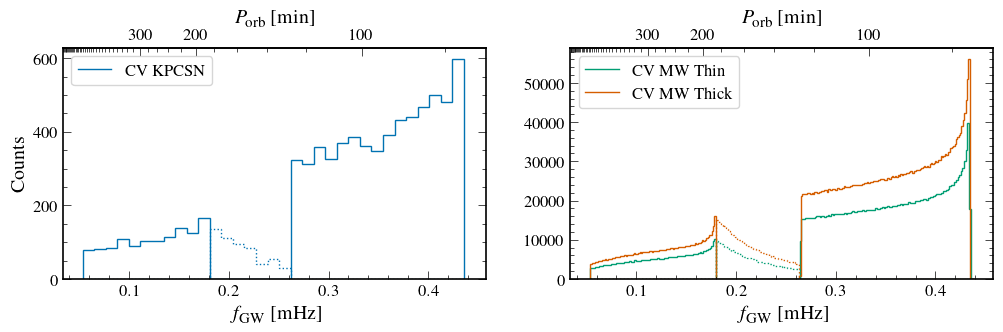

In [31]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 3), sharex=True)


kpccts, kpcbins = cvpop_frequency_hist_noEMedge(cvkpc, plot=False)

ax[0].stairs(kpccts, kpcbins*1e3, color='C0', label='CV KPCSN');
ax[0].hist(cvkpcgap['# f_gw[Hz]']*1e3, kpcbins*1e3, histtype='step', color='C0', linestyle='dotted');
ax[0].set_ylabel('Counts', fontsize='x-large')

thincts, thinbins = cvpop_frequency_hist_noEMedge(cvthin, plot=False)
thickcts, thickbins = cvpop_frequency_hist_noEMedge(cvthick, plot=False)

ax[1].stairs(thincts, thinbins*1e3, label='CV MW Thin', color='C1')
ax[1].hist(cvthingap['# f_gw[Hz]']*1e3, thinbins*1e3, histtype='step', color='C1', linestyle='dotted');

ax[1].stairs(thickcts, thickbins*1e3, label='CV MW Thick', color='C2')
ax[1].hist(cvthickgap['# f_gw[Hz]']*1e3, thickbins*1e3, histtype='step', color='C2', linestyle='dotted');

ax[0].tick_params(top=False, which='both', labelsize='large')
ax[1].tick_params(top=False, which='both', labelsize='large')


def gw_mHz_to_P_orb(gw_mHz): # LSS convert fgw to porb in minutes
    return (2 / (gw_mHz * 1e-3))/60

def P_orb_to_gw_mHz(P_orb):
    return (2 / (P_orb*60)) * 1e3 # LSS convert porb in minutes to fgw in mHz

secax0 = ax[0].secondary_xaxis('top', functions=(gw_mHz_to_P_orb, P_orb_to_gw_mHz))
secax0.set_xlabel(r'$P_{\rm orb}$ [min]', fontsize='x-large')
secax0.set_xticks([100, 200, 300])
secax0.tick_params(labelsize='large')
secax1 = ax[1].secondary_xaxis('top', functions=(gw_mHz_to_P_orb, P_orb_to_gw_mHz))
secax1.set_xlabel(r'$P_{\rm orb}$ [min]', fontsize='x-large')
secax1.set_xticks([100, 200, 300])
secax1.tick_params(labelsize='large')
    
ax[0].legend(fontsize='large')
ax[1].legend(fontsize='large')
ax[0].set_xlabel(r'$f_{\rm GW}$ [mHz]', fontsize='x-large')
ax[1].set_xlabel(r'$f_{\rm GW}$ [mHz]', fontsize='x-large')

plt.savefig('/home/levis/lisa_projects/blip_CVs/figures/paperfigs/fig1_freqdist.pdf', bbox_inches='tight', dpi=400, format='pdf')
plt.show()

## Scratch - plotting fixed CV oss2par model

In [17]:
# 1 year
fixcv_dbtpl = pkl.load(open('/home/levis/lisa_projects/blip_CVs/storage/run_outputs/prod3/fixoss2tsts/dur3p2e7_inj_oss2parfixgal_GBpop2_rec_n_allfixedoss2parfixedgal_DBTPLfixgal/plot_data.pickle', 'rb'))
gbcontrol = pkl.load(open('/home/levis/lisa_projects/blip_CVs/storage/run_outputs/prod3/DBTPL_GBpop_control/dur3p2e7_inj_GBpop2_rec_n_dblbroketruncpowlawfixedgal/plot_data.pickle', 'rb'))


In [10]:
fixcv_dbtpl['fit_data']['det_fits']

{'noise': {'median': array([6.74192174e-38, 5.58511666e-38, 4.67034561e-38, ...,
         3.76516295e-41, 3.76849321e-41, 3.77182484e-41], shape=(1981,)),
  'upper95': array([6.81935893e-38, 5.64921861e-38, 4.72390501e-38, ...,
         3.77399899e-41, 3.77733863e-41, 3.78067934e-41], shape=(1981,)),
  'lower95': array([6.66634389e-38, 5.52257190e-38, 4.61808860e-38, ...,
         3.75602165e-41, 3.75934356e-41, 3.76266654e-41], shape=(1981,))},
 'ALLFIXEDCVthinonesidestep2par_fixedgalaxy': {'median': array([6.50662940e-41, 6.40162616e-41, 6.30308499e-41, ...,
         1.18982937e-92, 1.18952011e-92, 1.18921098e-92], shape=(1981,)),
  'upper95': array([6.50662940e-41, 6.40162616e-41, 6.30308499e-41, ...,
         1.18982937e-92, 1.18952011e-92, 1.18921098e-92], shape=(1981,)),
  'lower95': array([6.50662940e-41, 6.40162616e-41, 6.30308499e-41, ...,
         1.18982937e-92, 1.18952011e-92, 1.18921098e-92], shape=(1981,))},
 'doublebrokentruncpowerlaw_fixedgalaxy': {'median': array([6.78

Text(0, 0.5, 'XX Autopower PSD [$\\rm{Hz }^{-1}$]')

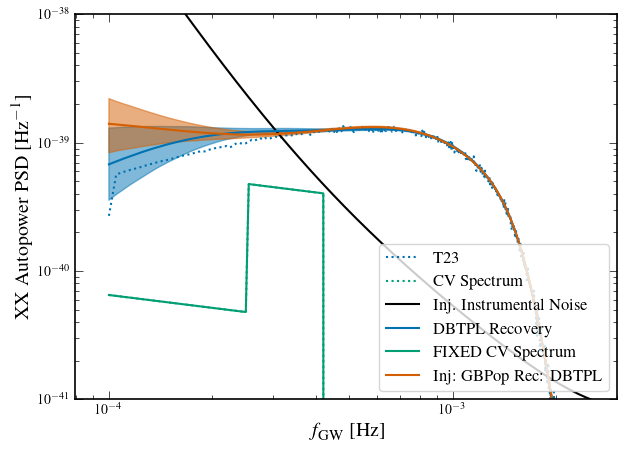

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))

# populations.
ax.plot(fixcv_dbtpl['fit_data']['fs'], fixcv_dbtpl['fit_data']['det_inj']['population-2']['spec'], label='T23', color='C0', linestyle='dotted')
ax.plot(fixcv_dbtpl['fit_data']['fs'], fixcv_dbtpl['fit_data']['det_inj']['onesidestep2par_fixedgalaxy']['spec'], label='CV Spectrum', color='C1', linestyle='dotted')


# noise
ax.plot(fixcv_dbtpl['fit_data']['fs'], fixcv_dbtpl['fit_data']['det_inj']['noise']['spec'], label='Inj. Instrumental Noise', color='k')

# recoveries
ax.plot(fixcv_dbtpl['fit_data']['fs'], fixcv_dbtpl['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['median'], label='DBTPL Recovery', color='C0')
ax.plot(fixcv_dbtpl['fit_data']['fs'], fixcv_dbtpl['fit_data']['det_fits']['ALLFIXEDCVthinonesidestep2par_fixedgalaxy']['median'], label='FIXED CV Spectrum', color='C1')
ax.fill_between(fixcv_dbtpl['fit_data']['fs'], fixcv_dbtpl['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['lower95'], fixcv_dbtpl['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['upper95'], alpha=0.5, color='C0')
 
# no CV injected control
ax.plot(gbcontrol['fit_data']['fs'], gbcontrol['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['median'], label='Inj: GBPop Rec: DBTPL', color='C2')
ax.fill_between(gbcontrol['fit_data']['fs'], gbcontrol['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['lower95'], gbcontrol['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['upper95'], alpha=0.5, color='C2')


ax.loglog()
ax.set_xlim(right=3e-3)
ax.legend(loc='lower right', fontsize='large')
ax.set_ylim(bottom=1e-41, top=1e-38)
ax.set_xlabel(r'$f_{\rm GW}$ [Hz]', fontsize='x-large')
ax.set_ylabel(r'XX Autopower PSD [$\rm{Hz }^{-1}$]', fontsize='x-large')
# plt.savefig('/home/schultls/levi_schult/blip_CVs/notebooks/figures/paperfigs/fig3_DWD_bias_comparison.pdf', bbox_inches='tight', dpi=400, format='pdf')